# Adaptive Fintech Fraud Detection – Analysis

This notebook is used for data exploration, feature engineering,
risk scoring, and model evaluation using the project modules.


In [9]:
import sys
import os

sys.path.append(os.path.abspath(".."))


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../data/transactions.csv")
df.head()


,transaction_id,user_id,amount,hour,day,device,location,txn_type,is_foreign,label
0,TXN0001,U005,280,16,5,android,Pune,WALLET,0,0
1,TXN0002,U010,1067,2,3,android,London,UPI,1,0
2,TXN0003,U041,1654,19,5,ios,Delhi,WALLET,0,0
3,TXN0004,U047,2835,22,4,android,London,WALLET,1,0
4,TXN0005,U077,2433,23,4,ios,Mumbai,WALLET,0,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  1000 non-null   object
 1   user_id         1000 non-null   object
 2   amount          1000 non-null   int64 
 3   hour            1000 non-null   int64 
 4   day             1000 non-null   int64 
 5   device          1000 non-null   object
 6   location        1000 non-null   object
 7   txn_type        1000 non-null   object
 8   is_foreign      1000 non-null   int64 
 9   label           1000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


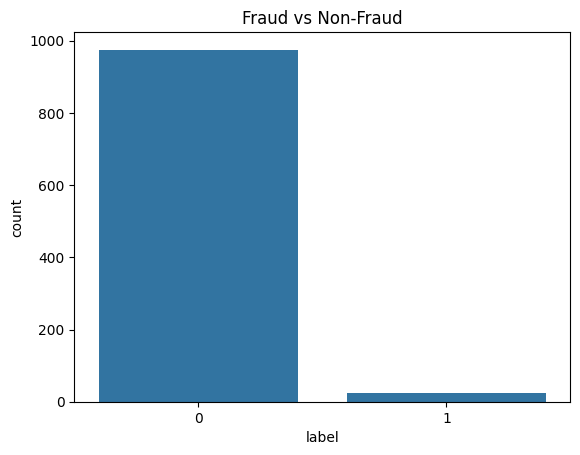

In [6]:
sns.countplot(x="label", data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()


In [10]:
from src.user_profiling import build_user_profiles

profiles = build_user_profiles(df)
profiles.head()


,user_id,avg_amount,std_amount,min_amount,max_amount,most_common_hour,most_common_location,most_common_device,txn_amount
0,U001,11228.625000,17686.714174,297,43228,14,Dubai,android,8
1,U002,11486.111111,14675.480890,220,34618,4,Chennai,web,9
2,U003,14058.000000,15594.410305,181,40256,2,Bangkok,android,9
3,U004,3084.230769,5588.415132,257,21522,3,Delhi,ios,13
4,U005,5360.500000,10509.697535,221,34218,10,London,ios,12


In [11]:
from src.feature_engineering import add_features

df_feat = add_features(df, profiles)
df_feat.head()


,transaction_id,user_id,amount,hour,day,device,location,txn_type,is_foreign,label,...,most_common_hour,most_common_location,most_common_device,txn_amount,amount_deviation,amount_zscore,unusual_hour,unusual_location,unusual_device,high_amount_flag
0,TXN0001,U005,280,16,5,android,Pune,WALLET,0,0,...,10,London,ios,12,5080.500000,0.483411,1,1,1,0
1,TXN0002,U010,1067,2,3,android,London,UPI,1,0,...,0,London,ios,7,7263.571429,0.539284,1,0,1,0
2,TXN0003,U041,1654,19,5,ios,Delhi,WALLET,0,0,...,17,London,ios,19,4044.105263,0.411701,1,1,0,0
3,TXN0004,U047,2835,22,4,android,London,WALLET,1,0,...,20,Delhi,web,8,12813.000000,0.788697,1,1,1,0
4,TXN0005,U077,2433,23,4,ios,Mumbai,WALLET,0,0,...,8,Bangalore,ios,9,6558.666667,0.593845,1,1,0,0


In [12]:
from src.risk_scoring import compute_risk_score

df_scored = compute_risk_score(df_feat)
df_scored[["amount", "risk_score"]].head()


,amount,risk_score
0,280,5.966821
1,1067,5.078568
2,1654,4.323403
3,2835,7.577393
4,2433,4.687690


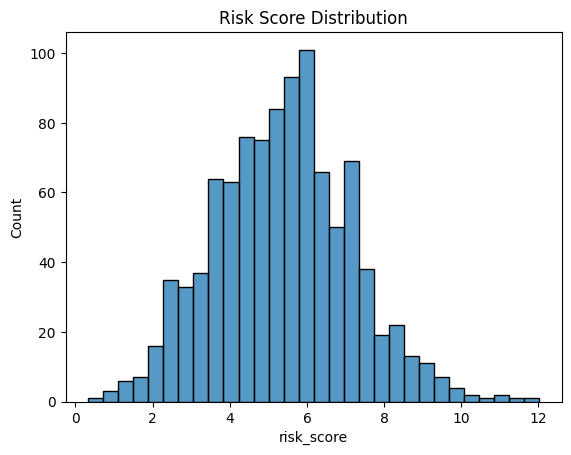

In [13]:
sns.histplot(df_scored["risk_score"], bins=30)
plt.title("Risk Score Distribution")
plt.show()


In [15]:
from src.train_model import train_fraud_model

model = train_fraud_model(df_scored)



MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       244
           1       0.00      0.00      0.00         6

    accuracy                           0.96       250
   macro avg       0.49      0.49      0.49       250
weighted avg       0.95      0.96      0.96       250



In [16]:
from src.decision_engine import apply_decision_layer

df_final = apply_decision_layer(df_scored)
df_final[["risk_score", "decision"]].head()


,risk_score,decision
0,5.966821,STEP_UP_AUTH
1,5.078568,STEP_UP_AUTH
2,4.323403,STEP_UP_AUTH
3,7.577393,BLOCK
4,4.687690,STEP_UP_AUTH
